$$
\begin{array}{l}
\quad \textbf{EMPIRICAL ANALYSIS OF THE EUR/USD EXCHANGE RATE AND YIELD SPREAD DYNAMICS} \\[2em]
\quad \text{The analysis focuses on the 2-year (2Y) government bond yield, as it closely reflects} \\
\quad \text{market expectations of future monetary policy. Bond prices and yields are inversely} \\
\quad \text{related: increases in demand raise bond prices and reduce yields, while selling pressure} \\
\quad \text{lowers prices and increases yields.} \\[1.2em]
\quad \text{Interest rates constitute a primary determinant of exchange rates, as they influence} \\
\quad \text{international capital flows by affecting the relative return on financial assets. In} \\
\quad \text{general, higher interest rates tend to support a currency, whereas lower rates exert} \\
\quad \text{depreciating pressure. Importantly, exchange rates respond more to expectations of} \\
\quad \text{future interest rate movements than to current levels.} \\[1.2em]
\quad \text{The 2Y yield therefore serves as a real-time proxy for market expectations regarding} \\
\quad \text{central bank actions over the short to medium term.} \\[1.2em]
\quad \text{Accordingly, the analysis focuses on changes in yields rather than their levels, and on} \\
\quad \text{the yield differential between the United States and Germany, the latter being the} \\
\quad \text{most relevant benchmark for the euro area. The objective is to assess whether variations} \\
\quad \text{in this spread—either widening or narrowing—are associated with movements in the} \\
\quad \text{EUR/USD exchange rate.} \\[1.2em]
\quad \text{To ensure comparability and reduce noise, the data are normalized prior to analysis.} \\[1.2em]
\quad \text{Finally, the empirical analysis aims to evaluate the existence and strength of a} \\
\quad \text{statistical relationship between changes in the yield spread and movements in the} \\
\quad \text{EUR/USD exchange rate.}
\end{array}
$$

In [2]:
# Analysis of the relation SPREAD 2Y Yields and the FX Rate EUR/USD
# We will try to see whether there is some correlation and how it is move and the degree of it 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import pearsonr
import statsmodels.api as sm

In [3]:
spread = pd.read_csv("data/US_DE_2Y_spread.csv")
eurusd = pd.read_csv("data/EURUSD_worked.csv")

In [4]:
eurusd.columns = ["Date", "EURUSD"]
spread["Date"] = pd.to_datetime(spread["Date"])
eurusd["Date"] = pd.to_datetime(eurusd["Date"])
eurusd["EURUSD"]=eurusd["EURUSD"].astype(float)
# to assure the same date format for the boths datasets
for dts in [spread, eurusd]:
    dts["Date"]=pd.to_datetime(dts["Date"])

In [5]:
# merge the two datasets
ds_merged=pd.merge(spread, eurusd, on="Date", how="inner")
ds_merged=ds_merged.sort_values("Date").reset_index(drop=True)

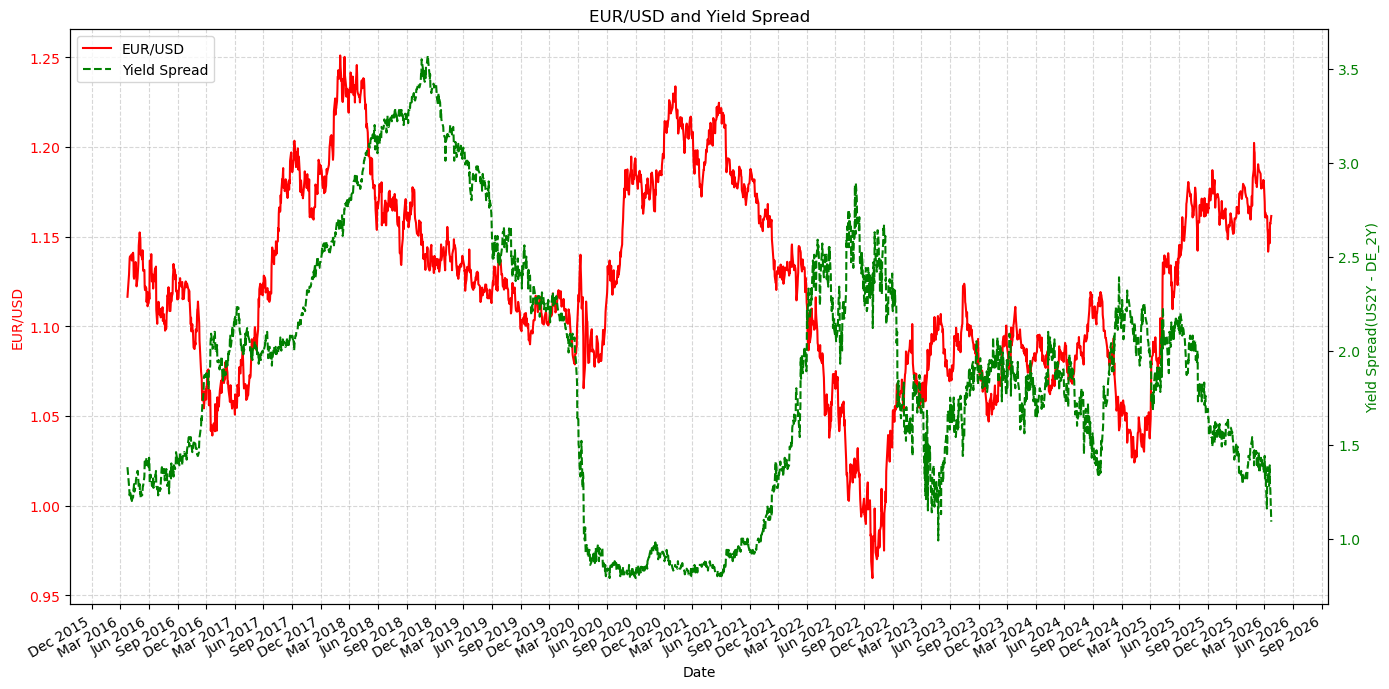

In [6]:
# plotting the 
# Create figure
fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(ds_merged["Date"], ds_merged["EURUSD"], color="red", linewidth=1.5, label="EUR/USD")
ax1.set_xlabel("Date")
ax1.set_ylabel("EUR/USD", color='red')
ax1.tick_params(axis="y", labelcolor='red')

# The data is displayed at three-month intervals to improve readability on the x-axis.
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax2=ax1.twinx()
ax2.plot(ds_merged["Date"], ds_merged["Spread"], color="green", linestyle="--", linewidth=1.5, label="Yield Spread")
# Right axis: Spread
ax2.set_ylabel("Yield Spread(US2Y - DE_2Y)", color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("EUR/USD and Yield Spread")
ax1.grid(True, linestyle="--", alpha=0.5)

lines1,labels1=ax1.get_legend_handles_labels()
lines2, labels2=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [60]:
# Pearson correlation coefficient
ds_merged["EURUSD"].corr(ds_merged["Spread"])

np.float64(-0.15287533944530796)

In [61]:
ds_merged

,Date,US_2Y,DE_2Y,Spread,EURUSD
0,2016-03-24,0.89,-0.49,1.38,1.11644
1,2016-03-29,0.78,-0.50,1.28,1.12892
2,2016-03-30,0.76,-0.49,1.25,1.13327
3,2016-03-31,0.73,-0.50,1.23,1.13785
4,2016-04-01,0.76,-0.49,1.25,1.13899
...,...,...,...,...,...
2445,2026-03-17,3.68,2.38,1.30,1.15387
2446,2026-03-18,3.76,2.37,1.39,1.14632
2447,2026-03-19,3.79,2.51,1.28,1.15763
2448,2026-03-20,3.88,2.62,1.26,1.15694


$$
\begin{array}{l}
\quad\quad\quad \text{The correlation between the yield spread and the EUR/USD exchange rate over the } \textbf{2016--2026} \\
\quad\quad\quad \text{period is approximately } \textbf{-0.15}, \text{ indicating a weak negative linear relationship.} \\[1em]
\quad\quad\quad \text{This suggests that, while the theoretical expectation is that a widening } \textbf{US--EU yield spread} \\
\quad\quad\quad \text{should lead to a depreciation of the euro (lower EUR/USD), the empirical relationship over this} \\
\quad\quad\quad \text{period is not strong.} \\[1em]
\quad\quad\quad \text{This weak correlation may be explained by the presence of multiple overriding factors such as} \\
\quad\quad\quad \text{monetary policy shifts, geopolitical events (e.g., COVID-19, wars), and market sentiment,} \\
\quad\quad\quad \text{which dilute the direct impact of yield differentials.} \\[2em]
\quad\quad\quad \text{Given the weak correlation observed in levels (} \textbf{-0.15} \text{), I decided to investigate whether the} \\
\quad\quad\quad \text{relationship is better captured in terms of } \textbf{changes}. \\[1em]
\quad\quad\quad \text{Therefore, I computed the Pearson correlation between the } \textbf{first differences} \text{ of the} \\
\quad\quad\quad \text{EUR/USD exchange rate and the first differences of the yield spread.} \\[1.5em]
\quad\quad\quad \text{The Pearson correlation is computed between the } \textbf{first differences} \text{ of the EUR/USD exchange} \\
\quad\quad\quad \text{rate and the yield spread.} \\[1em]
\quad\quad\quad \text{The first difference of a variable captures the } \textbf{variation between two consecutive} \\
\quad\quad\quad \textbf{observations}. \\[1em]
\quad\quad\quad\textbf{Mathematical definition of the first difference concept : }\\[1em]
\quad\quad\quad\quad\quad\quad\Delta X_t = X_t - X_{t-1}\\[1.5em]
\quad\quad\quad \text{In this context, it reflects the } \textbf{day-to-day changes} \text{ in both the EUR/USD exchange rate} \\
\quad\quad\quad \text{and the yield spread.} \\[1.5em]
\quad\quad\quad \text{By taking first differences, the analysis no longer focuses on the levels of the variables} \\
\quad\quad\quad \text{(EUR/USD level and yield spread level), but instead on their changes over time, namely:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \Delta \text{EUR/USD (change in the exchange rate)} \\
\quad\quad\quad\quad \bullet \ \Delta \text{Spread (change in the yield differential)} \\[1em]
\quad\quad\quad \text{This approach captures the } \textbf{short-term co-movement} \text{ between the two series.} \\[1em]
\quad\quad\quad \text{More formally, it estimates the } \textbf{contemporaneous linear relationship} \text{ between changes} \\
\quad\quad\quad \text{in the yield spread and changes in the EUR/USD exchange rate. It therefore provides a direct} \\
\quad\quad\quad \text{answer to the question: “When the yield spread changes, does EUR/USD move in the same} \\
\quad\quad\quad \text{direction at the same time?”} \\[1em]
\quad\quad\quad \text{The analysis is conducted on first-differenced series in order to } \textbf{isolate short-term dynamics} \\
\quad\quad\quad \text{and remove long-term trends.} \\[1em]
\quad\quad\quad \text{The resulting correlation reflects the contemporaneous relationship between variations in the} \\
\quad\quad\quad \text{interest rate differential and movements in the exchange rate, thereby focusing on } \textbf{new information} \\
\quad\quad\quad \text{rather than persistent levels.} \\[1em]
\quad\quad\quad \text{This transformation also mitigates issues related to } \textbf{non-stationarity} \text{ and allows for a more} \\
\quad\quad\quad \text{reliable assessment of the relationship between interest rate expectations and currency movements.} \\
\end{array}
$$

In [62]:
# first difference construction dataset
ds_merged["EURUSD_diff"]=ds_merged["EURUSD"].diff()
ds_merged["Spread_diff"]=ds_merged["Spread"].diff()
ds_merged

,Date,US_2Y,DE_2Y,Spread,EURUSD,EURUSD_diff,Spread_diff
0,2016-03-24,0.89,-0.49,1.38,1.11644,NaN,NaN
1,2016-03-29,0.78,-0.50,1.28,1.12892,0.01248,-0.10
2,2016-03-30,0.76,-0.49,1.25,1.13327,0.00435,-0.03
3,2016-03-31,0.73,-0.50,1.23,1.13785,0.00458,-0.02
4,2016-04-01,0.76,-0.49,1.25,1.13899,0.00114,0.02
...,...,...,...,...,...,...,...
2445,2026-03-17,3.68,2.38,1.30,1.15387,0.00404,0.02
2446,2026-03-18,3.76,2.37,1.39,1.14632,-0.00755,0.09
2447,2026-03-19,3.79,2.51,1.28,1.15763,0.01131,-0.11
2448,2026-03-20,3.88,2.62,1.26,1.15694,-0.00069,-0.02


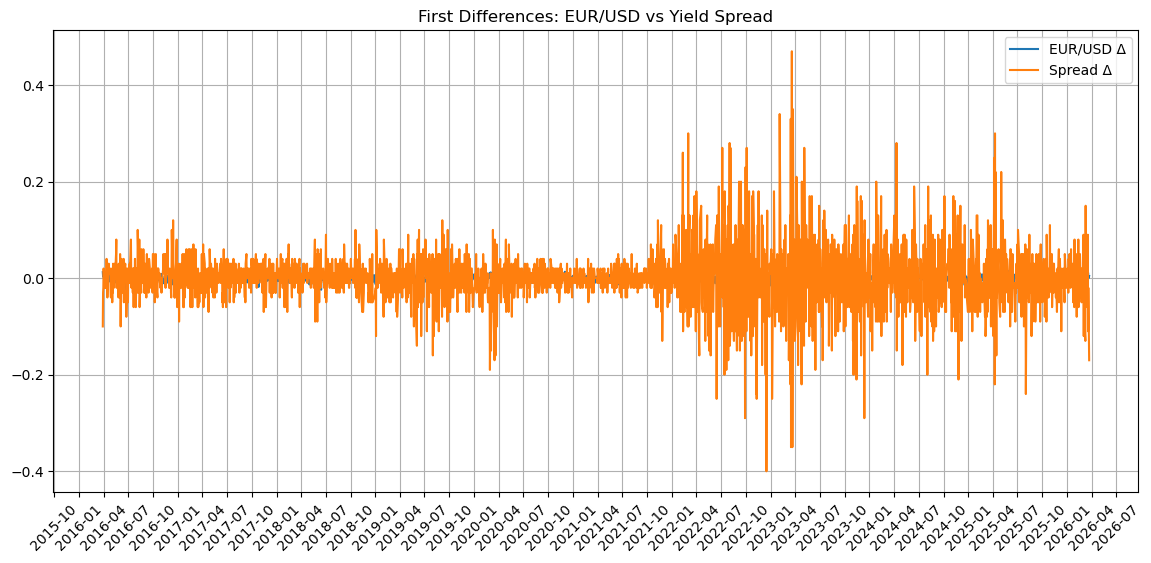

In [63]:
# Plot with raw data of first difference EURUSD , YieldSpread

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(ds_merged["Date"], ds_merged["EURUSD_diff"], label="EUR/USD Δ")
ax.plot(ds_merged["Date"], ds_merged["Spread_diff"], label="Spread Δ")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.legend()
ax.set_title("First Differences: EUR/USD vs Yield Spread")
ax.grid()

plt.show()

$$
\begin{array}{l}
\quad\quad\quad \textbf{Technical point of view:} \\[1em]
\quad\quad\quad\quad \bullet \ \text{Co-movement between the two series is } \textbf{not immediately observable} \\
\quad\quad\quad\quad \bullet \ \text{The dominance of spread volatility masks potential relationships} \\[1em]
\quad\quad\quad \text{Visual inspection alone is insufficient to assess the strength or direction of the relationship.} \\[1em]
\quad\quad\quad \text{This justifies:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{normalization (Z-scores)} \\
\quad\quad\quad\quad \bullet \ \text{correlation analysis} \\
\quad\quad\quad\quad \bullet \ \text{rolling correlation} \\[2em]
\quad\quad\quad \textbf{From a macro-financial perspective:} \\[1em]
\quad\quad\quad \text{Changes in the yield spread reflect shifts in relative monetary policy expectations.} \\[1em]
\quad\quad\quad \text{These shifts should theoretically influence } \textbf{EUR/USD}. \\[1em]
\quad\quad\quad \text{However, the figure suggests that:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{The transmission mechanism is not instantaneous} \\
\quad\quad\quad\quad \bullet \ \text{It may involve lags, asymmetries, or nonlinearities} \\
\end{array}
$$

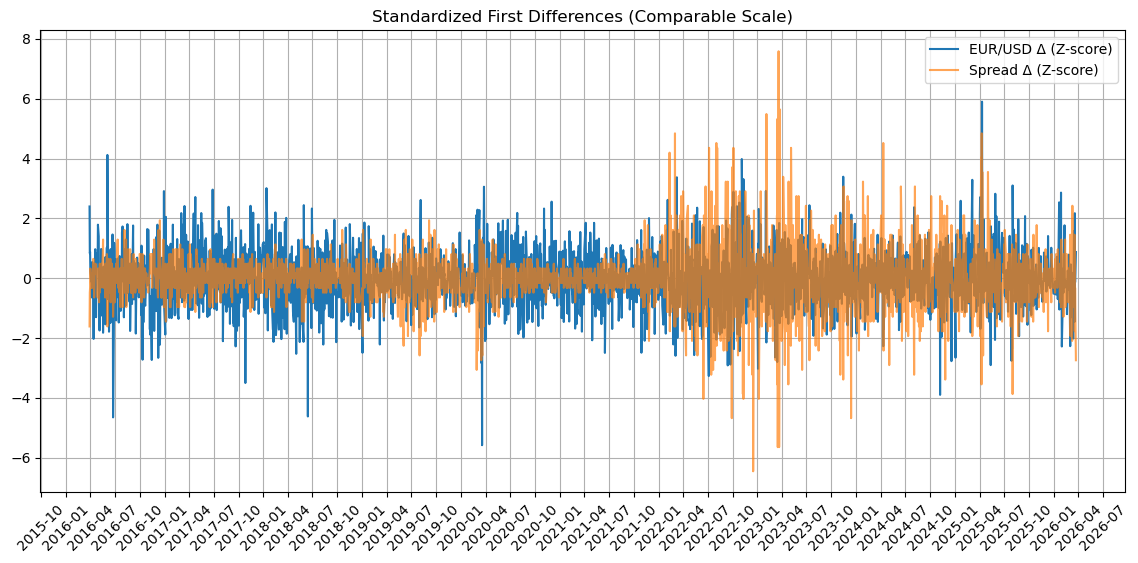

In [64]:
# Standardize (Z-score)
ds_merged["Spread_diff_Z"] = (ds_merged["Spread_diff"] - ds_merged["Spread_diff"].mean()) / ds_merged["Spread_diff"].std()
ds_merged["EURUSD_diff_Z"] = (ds_merged["EURUSD_diff"] - ds_merged["EURUSD_diff"].mean()) / ds_merged["EURUSD_diff"].std()

# Plot


fig, ax = plt.subplots(figsize=(14,6))

ax.plot(ds_merged["Date"], ds_merged["EURUSD_diff_Z"], label="EUR/USD Δ (Z-score)")
ax.plot(ds_merged["Date"], ds_merged["Spread_diff_Z"], label="Spread Δ (Z-score)", alpha=0.7)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.legend()
plt.title("Standardized First Differences (Comparable Scale)")
plt.grid()
plt.show()

$$
\begin{array}{l}
\quad\quad\quad \text{The figure presents the standardized first differences (Z-scores) of:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \Delta \text{EUR/USD} \\
\quad\quad\quad\quad \bullet \ \Delta \text{Spread} \\[1.5em]
\quad\quad\quad \text{Their standardization:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Z-score of } \Delta \text{EUR/USD}_t \\
\quad\quad\quad\quad \bullet \ \text{Z-score of } \Delta \text{Spread}_t \\[1.5em]
\quad\quad\quad\quad\quad\quad Z_t = \frac{X_t - \mu}{\sigma} \\[2em]
\quad\quad\quad \textbf{ensures both series are expressed in terms of standard deviations from their} \\
\quad\quad\quad \textbf{respective means, allowing direct comparison of their relative fluctuations.} \\[1em]
\quad\quad\quad \text{Thus, the graph reflects } \textbf{normalized changes} \text{, not absolute ones.} \\[1.5em]
\quad\quad\quad \text{The standardized representation allows a clearer visual assessment of } \textbf{co-movement:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Periods where both series move in the } \textbf{same direction} \text{ suggest positive} \\
\quad\quad\quad\quad \quad \text{contemporaneous association} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{Periods of } \textbf{opposite movement} \text{ indicate negative dependence} \\[1em]
\quad\quad\quad \textbf{However:} \\[0.5em]
\quad\quad\quad\quad \bullet \ \text{The relationship appears } \textbf{intermittent and unstable} \\
\quad\quad\quad\quad \bullet \ \text{No persistent one-to-one alignment is observed} \\[1em]
\quad\quad\quad \text{The correlation between the yield spread and EUR/USD is } \textbf{time-varying and potentially} \\
\quad\quad\quad \textbf{nonlinear}. \\
\end{array}
$$

$$
\begin{array}{l}
\quad\quad\quad \text{There appears to be a correlation between the two variables, consistent with evidence} \\
\quad\quad\quad \text{reported in the financial literature.} \\[1em]
\quad\quad\quad \text{The next step is to determine whether this relationship is } \textbf{statistically significant} \\
\quad\quad\quad \textbf{rather than driven by random noise.} \\[1em]
\quad\quad\quad \text{This is achieved by computing the } \textbf{Pearson correlation coefficient} \text{ and evaluating its} \\
\quad\quad\quad \textbf{associated p-value.} \\[2em]
\quad\quad\quad \textbf{Pearson correlation coefficient } r : \\[1em]
\quad\quad\quad\quad \text{Measures strength and direction of linear relationship} \\[0.5em]
\quad\quad\quad r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \, \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}} \\[2em]
\quad\quad\quad\quad \bullet \quad r \in [-1,1] \\[0.5em]
\quad\quad\quad\quad \bullet \quad r > 0 \ \rightarrow \ \text{same direction} \\[0.5em]
\quad\quad\quad\quad \bullet \quad r < 0 \ \rightarrow \ \text{opposite direction} \\[2em]
\quad\quad\quad\quad \bullet \quad r  \approx 0 \ \rightarrow \ \text{no linear link} \\[2em]
\quad\quad\quad \textbf{p-value (significance of } r\textbf{)}\\[1em]
\quad\quad\quad \text{Formula:} \\[0.5em]
\quad\quad\quad\quad t = \frac{r \sqrt{n-2}}{\sqrt{1 - r^2}} \\[0.5em]
\quad\quad\quad \text{Meaning:} \\[0.5em]
\quad\quad\quad\quad\quad \bullet \quad \text{Null hypothesis: } H_0: \ \rho = 0 \\[0.5em]
\quad\quad\quad\quad\quad \bullet \quad \text{Alternative hypothesis: } H_1: \ \rho \neq 0 \\[0.5em]
\quad\quad\quad\quad\quad \bullet \quad \rho \ (\text{rho}) \ \rightarrow \ \text{true population correlation} \\[0.5em]
\quad\quad\quad\quad\quad \bullet \quad \rho = 0 \ \rightarrow \ \textbf{no real relationship} \\[0.5em]
\quad\quad\quad\quad\quad \textbf{The p-value measures statistical significance} \\
\quad\quad\quad\quad\quad \textbf{It tells whether the observed correlation could have occurred by random chance} \\[1em]
\end{array}
$$

In [65]:
# p-value calculation
clean_data = ds_merged[["Date", "EURUSD_diff", "Spread_diff"]].dropna()

corr, p = pearsonr(clean_data["EURUSD_diff"], clean_data["Spread_diff"])

print(corr, p)

-0.25974713529320625 4.719256490931512e-39


$$
\begin{array}{l}
\quad\quad\quad \text{The Pearson correlation between first differences of the EUR/USD exchange rate and the} \\
\quad\quad\quad \text{yield spread is approximately } \textbf{-0.26}. \\[1em]
\quad\quad\quad \text{This relationship is } \textbf{statistically significant} \text{ at conventional levels } (p < 0.001), \\
\quad\quad\quad \text{indicating that the observed correlation is unlikely to be due to random variation.} \\[1em]
\quad\quad\quad \text{However, the magnitude of the correlation remains } \textbf{moderate}, \text{ suggesting that the} \\
\quad\quad\quad \text{yield spread explains only a limited portion of short-term exchange rate movements.} \\[1em]
\quad\quad\quad \text{The negative sign of the correlation is consistent with } \textbf{theoretical expectations}, \text{ as an} \\
\quad\quad\quad \text{increase in the yield spread (favoring US assets) is associated with a depreciation of the} \\
\quad\quad\quad \text{euro against the US dollar.} \\
\end{array}
$$

$$
\begin{array}{1}
\quad\quad\quad\quad\quad \Large \textbf{PERIOD DECOMPOSITION} \\[3em]
\end{array}
$$

$$
\begin{array}{l}
\quad\quad\quad \text{To obtain a more nuanced understanding of the relationship between these two variables, it is} \\
\quad\quad\quad \text{methodologically appropriate to decompose the overall period (2016--2026) into several} \\
\quad\quad\quad \text{subperiods. This segmentation allows for a more precise identification of their } \textbf{dynamic} \\
\quad\quad\quad \textbf{interdependencies} \text{ and facilitates the detection of potential structural changes in their relationship.} \\[1em]
\quad\quad\quad \text{Such an approach is particularly relevant in the presence of } \textbf{major exogenous shocks} \text{---} \\
\quad\quad\quad \text{such as geopolitical conflicts or global crises---which may temporarily distort or even override} \\
\quad\quad\quad \text{the underlying macroeconomic mechanisms governing the variables.} \\[1em]
\quad\quad\quad \text{Accordingly, the analysis is structured around the following subperiods:}
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{Period 1: 2016 -- Feb 2020} \\[0.3em]
\quad \textit{Pre-COVID / Low-rate environment} \\[0.5em]
\quad\quad \bullet \ \text{Stable monetary policy} \\
\quad\quad \bullet \ \text{Low inflation} \\
\quad\quad \bullet \ \text{Weak yield spread dynamics} \\[1.2em]
\quad \textbf{Period 2: Mar 2020 -- Dec 2021} \\[0.3em]
\quad \textit{COVID shock \& policy intervention} \\[0.5em]
\quad\quad \bullet \ \text{Massive central bank stimulus} \\
\quad\quad \bullet \ \text{Near-zero rates} \\
\quad\quad \bullet \ \text{Distorted yield signals} \\[1.2em]
\quad \textbf{Period 3: 2022 -- 2026} \\[0.3em]
\quad \textit{Wars \& Inflation shock \& monetary tightening} \\[0.5em]
\quad\quad \bullet \ \text{Fed hiking aggressively} \\
\quad\quad \bullet \ \text{ECB lagging initially} \\
\quad\quad \bullet \ \text{Strong yield spread movements} \\
\quad\quad \bullet \ \text{Geopolitical shocks (Ukraine, energy crisis)}
\end{array}
$$

In [66]:
#temporal segmentation, three periods
p_precovid=clean_data[clean_data["Date"]<"2020-03-01"]
p_covid=clean_data[
    (clean_data["Date"]>="2020-03-01") &
    (clean_data["Date"]<="2021-12-31")
]
p_wartime=clean_data[clean_data["Date"]>="2022-01-01"]




In [67]:
# correlation coefficient an dp-value for pre covid period from 2016-03 till 2020-03-01
corr, p = pearsonr(p_precovid["EURUSD_diff"], p_precovid["Spread_diff"])

print(corr, p)

-0.23778549666611068 8.564357552783145e-14


In [68]:
# correlation coefficient an dp-value for covid period from 2020-03 till 2022-12-31
corr, p = pearsonr(p_covid["EURUSD_diff"], p_covid["Spread_diff"])

print(corr, p)

-0.17416341206180594 0.00019521863622899333


In [69]:
# correlation coefficient an dp-value for wartime period from 2022-01 till 2026-03
corr, p = pearsonr(p_wartime["EURUSD_diff"], p_wartime["Spread_diff"])

print(corr, p)

-0.3105474497827252 1.2770672525280801e-24


$$
\begin{array}{lccc}
\quad \textbf{Period} & \textbf{Correlation (r)} & \textbf{p-value} & \textbf{Interpretation} \\[0.5em]
\hline \\[-0.3em]
\quad \text{Pre-COVID} & -0.238 & 8.56 \times 10^{-14} & \text{Moderate negative} \\[0.5em]
\quad \text{COVID} & -0.174 & 1.95 \times 10^{-4} & \text{Weak negative} \\[0.5em]
\quad \text{Wartime} & -0.311 & 1.27 \times 10^{-24} & \text{Stronger negative} \\[0.5em]
\quad \textbf{Full Period (2016--2026)} & \textbf{-0.260} & \mathbf{4.72 \times 10^{-39}} & \textbf{Moderate negative}
\end{array}
$$

$$
\begin{array}{l}
\quad \text{The estimated Pearson correlation coefficient between the first differences of the EUR/USD} \\
\quad \text{exchange rate and the yield spread is } \textbf{negative and statistically significant} \text{ across all} \\
\quad \text{subperiods, as evidenced by the extremely low p-values.} \\[1em]
\quad \text{However, the magnitude of the correlation remains } \textbf{relatively modest}, \text{ indicating a weak} \\
\quad \text{linear relationship between the two variables.} \\[1.5em]
\quad \text{This limited strength is further reflected in the } \textbf{coefficient of determination}, \text{ which measures} \\
\quad \text{the proportion of variance explained:} \\[1em]
\quad\quad\quad \mathbf{R}^2 = \mathbf{r}^2 \\
\end{array}
$$

In [70]:
# the coefficient of determination for each subperiod and he whole one
R2_precovid = p_precovid["EURUSD_diff"].corr(p_precovid["Spread_diff"])**2
R2_covid = p_covid["EURUSD_diff"].corr(p_covid["Spread_diff"])**2
R2_wartime = p_wartime["EURUSD_diff"].corr(p_wartime["Spread_diff"])**2
R2_whole=clean_data["EURUSD_diff"].corr(clean_data["Spread_diff"])**2
print(f"R2_precovid: {R2_precovid}")
print(f"R2_covid: {R2_covid}")
print(f"R2_wartime: {R2_wartime}")
print(f"R2_whole: {R2_whole}")

R2_precovid: 0.05654194242474895
R2_covid: 0.03033289410101047
R2_wartime: 0.09643971856655437
R2_whole: 0.06746857429302713


$$
\begin{array}{lccc}
\quad \textbf{Period} & \textbf{r} & \mathbf{R^2} & \textbf{Interpretation} \\[0.5em]
\hline \\[-0.3em]
\quad \text{Pre-COVID} & -0.238 & 0.057 & \sim 5.7\% \ \text{explained} \\[0.5em]
\quad \text{COVID} & -0.174 & 0.030 & \sim 3.0\% \ \text{explained} \\[0.5em]
\quad \text{Wartime} & -0.311 & 0.097 & \sim 9.7\% \ \text{explained} \\[0.5em]
\quad \text{Whole} & -0.260 & 0.068 & \sim 6.8\% \ \text{explained}
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{The relatively low values of } R^2 \textbf{ suggest that the spread accounts for only a limited} \\
\quad \textbf{fraction of the total variance, implying that the relationship, while robust, is weak in} \\
\quad \textbf{explanatory power.} \\[7em]
\end{array}
$$

$$
\begin{array}{l}
\quad\quad\quad\quad\quad\quad\quad \Large \textbf{ECONOMIC INTERPRETATIONS} \\[4em]
\quad \text{The results indicate a statistically significant negative correlation between changes in the} \\
\quad \text{EUR/USD exchange rate and changes in the yield spread across all considered periods.} \\
\quad \text{However, this relationship exhibits substantial time variation, suggesting the presence of} \\
\quad \textbf{regime-dependent dynamics}. \\[1.2em]
\quad \textbf{Pre-COVID period} \\[0.5em]
\quad \text{During the pre-COVID period, the correlation is moderately negative } (r = -0.238), \\
\quad \text{indicating a stable inverse relationship between the exchange rate and the yield spread.} \\
\quad \text{This is consistent with standard macro-financial theory, whereby an increase in the} \\
\quad \text{US--EU yield differential tends to appreciate the US dollar relative to the euro.} \\[1.2em]
\quad \textbf{COVID period} \\[0.5em]
\quad \text{During the COVID period, the correlation weakens } (r = -0.174), \text{ although it remains} \\
\quad \text{statistically significant. This attenuation suggests that conventional interest rate} \\
\quad \text{differentials played a less dominant role, likely overshadowed by extraordinary factors such} \\
\quad \text{as global risk aversion, monetary policy interventions, and liquidity shocks.} \\[1em]
\quad \textbf{Wartime period (post-2022)} \\[0.5em]
\quad \text{In the wartime period, the correlation strengthens markedly } (r = -0.311), \text{ indicating a more} \\
\quad \text{pronounced sensitivity of the exchange rate to yield differentials. This may reflect the} \\
\quad \text{re-emergence of interest rate expectations as a key driver, alongside heightened geopolitical} \\
\quad \text{risk and energy market disruptions affecting the euro area.} \\[1.2em]
\quad \text{Over the full sample (2016--2026), the correlation remains moderately negative } (r = -0.260), \\
\quad \text{but this aggregate measure conceals significant heterogeneity across subperiods. The} \\
\quad \text{variation in correlation strength highlights the importance of } \textbf{temporal segmentation} \\
\quad \text{when analyzing exchange rate determinants.} \\[2em]
\quad \text{Yield spread explains only a small fraction of EUR/USD movements,}\\
\quad \text{confirming that exchange rate dynamics are driven by multiple interacting factors.}
\end{array}
$$

$$
\begin{array}{l}
\Large \textbf{NEXT STEP:} \\[2em]
\quad \text{Having established the extent to which the yield spread explains variations in EUR/USD,} \\
\quad \text{it is now important to examine how } \textbf{changes in the spread} \text{ affect the exchange rate.} \\[1em]
\quad \text{A } \textbf{regression framework} \text{ is therefore employed to formally assess the impact of yield} \\
\quad \text{spread movements on EUR/USD dynamics.}
\end{array}
$$

In [71]:
# Regression
X = clean_data["Spread_diff"]
y = clean_data["EURUSD_diff"]
X = sm.add_constant(X)  # adds alpha
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            EURUSD_diff   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     177.0
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           4.72e-39
Time:                        01:14:42   Log-Likelihood:                 9492.4
No. Observations:                2449   AIC:                        -1.898e+04
Df Residuals:                    2447   BIC:                        -1.897e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.582e-05      0.000      0.156      

$$
\begin{array}{l}
\quad\quad\quad\quad\quad \Large\textbf{Linear Rregression explanation} \\[2em]
\quad \text{The relationship between changes in the EUR/USD exchange rate and changes in the} \\
\quad \text{yield spread is modeled using a linear regression of the following form:} \\[1em]
\quad \Delta \text{EUR/USD}_t = \alpha + \beta \cdot \Delta \text{Spread}_t + \varepsilon_t \\[1.5em]
\quad \Delta \text{EUR/USD}_t \quad \text{-- the change in EUR/USD at time } t \\[0.5em]
\quad \Delta \text{Spread}_t \quad \text{-- the change in the yield spread (US2Y -- DE2Y)} \\[0.5em]
\quad \alpha \ \text{-- intercept (constant term)} \\[0.5em]
\quad \beta \ \text{-- sensitivity of EUR/USD to changes in the yield spread} \\[0.5em]
\quad \varepsilon_t \ \text{-- error term capturing other influences} \\[1.5em]
\quad \alpha = \mathbb{E} \left[ \Delta \text{EUR/USD}_t \mid \Delta \text{Spread}_t = 0 \right] \\[1em]
\quad \text{It represents the expected change in EUR/USD when the spread does not change.} \\[0.5em]
\quad \text{It represents the } \textbf{baseline movement} \text{ of EUR/USD independent of the yield spread.} \\[1em]
\quad \beta \ \text{is the } \textbf{slope coefficient} \text{ of the regression.} \\[1.5em]
\quad \beta = \frac{\partial \ \Delta \text{EUR/USD}_t}{\partial \ \Delta \text{Spread}_t} \\[1.5em]
\quad \text{It measures the } \textbf{marginal effect} \text{ of the spread on EUR/USD.} \\[0.5em]
\quad \text{That is, how much EUR/USD changes when the yield spread changes by one unit.}\\[0.5em]
\quad \varepsilon_t \ \text{is the } \textbf{error term} \text{ (also called residual).} \\[1em]
\quad \varepsilon_t = \Delta \text{EUR/USD}_t - (\alpha + \beta \cdot \Delta \text{Spread}_t) \\[1.5em]
\quad \text{Observed FX move} = \text{Explained part} + \text{Unexplained part} \\[0.8em]
\quad\quad \bullet \ \text{Explained} = \alpha + \beta \cdot \Delta \text{Spread}_t \\
\quad\quad \bullet \ \text{Unexplained} = \varepsilon_t \\[1.2em]
\quad \varepsilon_t \ \text{contains } \textbf{everything not captured by the yield spread} \\[1em]
\quad \textbf{Examples:} \\[0.5em]
\quad\quad \bullet \ \text{geopolitical shocks (war, crisis)} \\
\quad\quad \bullet \ \text{energy prices (gas, oil --- very important for EUR)} \\
\quad\quad \bullet \ \text{inflation surprises} \\
\quad\quad \bullet \ \text{central bank communication} \\
\quad\quad \bullet \ \text{risk sentiment (flight to safety)}\\
\quad\quad \bullet \ \text{market noise}\\
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{}\beta \textbf{ coefficient} \\[1em]
\quad \textbf{Estimated coefficient:} \\[0.5em]
\quad \beta = -0.0218 \\[1.5em]
\quad \textbf{Interpretation:} \\[0.5em]
\quad\quad \bullet \ \text{A 1-unit increase in the yield spread change (0.01 = 1 basis point)} \\
\quad\quad \quad \text{leads to a } \textbf{-0.0218 decrease} \text{ in EUR/USD change (≈ -2.18 pips)} \\[1.5em]
\quad \textbf{If:} \\[0.5em]
\quad\quad \Delta \text{Spread} = 0.01 \quad \text{(1 basis point)} \\[1em]
\quad \textbf{Then:} \\[0.5em]
\quad\quad \Delta \text{EUR/USD} = -0.0218 \times 0.01 = -0.000218 \\[1.5em]
\quad \textbf{Economic meaning:} \\[0.5em]
\quad \text{The estimated coefficient suggests that a 1 basis point increase in the yield spread is} \\
\quad \text{associated with an approximate decrease of 0.000218 in EUR/USD, indicating a} \\
\quad \textbf{negative sensitivity} \text{ of the exchange rate to interest rate differentials.}
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{F-statistic:} \\[0.5em]
\quad \textbf{Overall model significance} \\[1em]
\quad F = 177, \quad p \approx 4.7 \times 10^{-39} \\[1.2em]
\quad \checkmark \ \text{The model is } \textbf{globally significant} \\[1.5em]
\quad \textbf{The F-test compares:} \\[0.5em]
\quad\quad \textbf{Explained variation (signal)} \quad \text{vs} \quad \textbf{Unexplained variation (noise)} \\[1.2em]
\quad \textbf{Interpretation:} \\[0.5em]
\quad\quad \bullet \ \text{If } F \text{ is small } \Rightarrow \ \text{model has little explanatory power} \\
\quad\quad \bullet \ \text{If } F \text{ is large } \Rightarrow \ \text{model explains a meaningful share of variation} \\[1.5em]
\quad F = 177, \quad p \approx 4.7 \times 10^{-39} \\[1em]
\quad \text{This result is highly statistically significant, indicating that the probability that the} \\
\quad \text{model has no explanatory power is essentially zero.}
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{Intercept } (\alpha): \\[1em]
\quad \alpha = 1.58 \times 10^{-5}, \quad p = 0.876 \\[1.5em]
\quad\quad \bullet \ \text{Not statistically significant} \\
\quad\quad \bullet \ \text{Approximately equal to zero} \\[0.5em]
\quad\quad \checkmark \ \text{No systematic drift in EUR/USD changes when the spread is zero} \\[1.5em]
\quad \textbf{Interpretation:} \\[0.5em]
\quad \text{The intercept term is not statistically different from zero } (p = 0.876), \text{ indicating that,} \\
\quad \text{in the absence of changes in the yield spread, there is no evidence of a systematic drift} \\
\quad \text{in EUR/USD returns. The exchange rate changes are therefore centered around zero} \\
\quad \text{when the spread remains constant.}
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{Durbin--Watson:} \\[0.5em]
\quad \textbf{Residual diagnostics} \\[1em]
\quad DW \approx 2.05 \\[1.2em]
\quad \textbf{No autocorrelation} \\
\quad \textbf{Residuals behave like white noise} \\[1.5em]
\quad \text{The Durbin--Watson statistic (DW) tests whether residuals are correlated over time,} \\
\quad \text{i.e., whether present errors are related to past errors.} \\[1em]
\quad \text{This result is close to 2:} \\[0.5em]
\quad\quad \bullet \ \text{No autocorrelation in residuals} \\
\quad\quad \bullet \ \text{Errors are independent over time} \\[1.2em]
\quad DW \approx 2 \ \text{implies:} \\[0.5em]
\quad\quad \bullet \ \text{The unexplained component is } \textbf{random} \\
\quad\quad \bullet \ \text{It is not predictable from past information}
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{Jarque--Bera test:} \quad p \approx 0, \quad \text{Kurtosis} \approx 4.93 \\[1em]
\quad \textbf{Residuals are not normally distributed} \\[1.2em]
\quad \text{The Jarque--Bera test strongly rejects the null hypothesis of normality } (p \approx 0), \\
\quad \text{indicating that the residuals are not normally distributed. The elevated kurtosis} \\
\quad \text{(≈ 4.93) suggests the presence of } \textbf{fat tails}, \text{ implying a higher frequency of} \\
\quad \text{extreme deviations than predicted by a normal distribution.} \\[1.5em]
\quad \textbf{Economic meaning:} \\[0.5em]
\quad \text{This behavior is consistent with well-documented } \textbf{stylized facts} \text{ of financial time series.} \\[0.8em]
\quad\quad \bullet \ \text{Fat tails (extreme events occur more frequently)} \\
\quad\quad \bullet \ \text{Volatility clustering} \\
\quad\quad \bullet \ \text{Sensitivity to news shocks} \\[1.2em]
\quad \text{The unexplained component of EUR/USD contains large and unpredictable movements,} \\
\quad \text{reflecting the presence of } \textbf{tail risk} \text{ in financial markets.}
\end{array}
$$

$$
\begin{array}{l}
\textbf{Confidence interval for } \beta \\[1em]
\quad \beta \in [-0.025,\,-0.019] \\[1.5em]
\quad \textbf{Always negative } \Rightarrow \ \textbf{robust relationship} \\[1.2em]
\quad \text{We are approximately 95\% confident that the true effect of the yield spread} \\
\quad \text{on EUR/USD lies between } -0.025 \text{ and } -0.019. \\[1em]
\quad \textbf{The interval is entirely negative} \\[0.5em]
\quad \textbf{The effect is consistently negative, not just due to chance}
\end{array}
$$

$$
\begin{array}{l}
\quad\quad\quad\quad\quad\quad\Large \textbf{LINEAR REGRESSION CONCLUSION} \\[3em]
\quad \text{The estimated OLS regression reveals a } \textbf{negative and statistically significant} \text{ relationship} \\
\quad \text{between changes in the yield spread and changes in the EUR/USD exchange rate. The} \\
\quad \text{coefficient associated with the spread differential } (\beta = -0.0218) \text{ indicates that an increase} \\
\quad \text{in the yield spread leads to a depreciation of the euro against the US dollar, consistent} \\
\quad \text{with standard interest rate parity intuition.} \\[1.2em]
\quad \text{Despite its statistical significance, the explanatory power of the model remains limited} \\
\quad (R^2 = 0.067), \text{ suggesting that yield differentials capture only a small fraction of} \\
\quad \text{short-term exchange rate movements. This highlights the importance of additional} \\
\quad \text{macroeconomic and financial factors in driving EUR/USD dynamics.} \\[1.2em]
\quad \text{Diagnostic tests indicate no significant autocorrelation in residuals } (DW \approx 2.05), \\
\quad \text{although deviations from normality are observed, reflecting the presence of } \textbf{fat tails} \\
\quad \text{typical in financial time series.} \\[2em]
\quad \textbf{Next step:} \\[1em]
\quad \textbf{Lags (1--30 days) } \Rightarrow \ \textbf{Lead--lag structure} \\[1.2em]
\quad \text{Markets do not react instantaneously. The current model assumes a contemporaneous} \\
\quad \text{relationship:} \\[1em]
\quad \Delta \text{EUR/USD}_t = \beta \cdot \Delta \text{Spread}_t + \varepsilon_t \\[1.2em]
\quad \text{This implies that EUR/USD moves at the same time as the yield spread.} \\[1.2em]
\quad \text{In reality, adjustments may be delayed. A more realistic specification is:} \\[1em]
\quad \Delta \text{EUR/USD}_t = \beta \cdot \Delta \text{Spread}_{t-k} + \varepsilon_t \\[1.2em]
\quad \text{where } k \text{ represents the lag.} \\[1.5em]
\quad \textbf{Objective:} \\[0.5em]
\quad \text{Identify whether the yield spread leads EUR/USD (or vice versa).} \\[1.2em]
\quad \textbf{Interpretation:} \\[0.5em]
\quad \text{If the strongest relationship occurs at } k = 3, \text{ then changes in the spread predict} \\
\quad \text{EUR/USD movements 3 days ahead.}
\end{array}
$$

In [72]:
# Cross-Correlation Analysis of Lagged Relationships
lag_results = []

for k in range(1, 31):
    temp = clean_data.copy()
    
    # shift spread backward in time: Spread_(t-k)
    temp["Spread_lag"] = temp["Spread_diff"].shift(k)
    
    # keep only rows where both variables exist
    temp = temp[["EURUSD_diff", "Spread_lag"]].dropna()
    
    # compute correlation
    corr = temp["EURUSD_diff"].corr(temp["Spread_lag"])
    
    lag_results.append((k, corr))

lag_df = pd.DataFrame(lag_results, columns=["Lag", "Correlation"])
print(lag_df)

    Lag  Correlation
0     1    -0.016340
1     2     0.005184
2     3    -0.009047
3     4    -0.020161
4     5    -0.006837
5     6    -0.016343
6     7    -0.018763
7     8     0.031869
8     9     0.008241
9    10     0.009614
10   11     0.032989
11   12     0.010691
12   13    -0.018706
13   14    -0.043492
14   15     0.032924
15   16    -0.001275
16   17    -0.001291
17   18    -0.039087
18   19     0.015027
19   20    -0.000314
20   21     0.002939
21   22     0.005319
22   23    -0.014118
23   24     0.034731
24   25    -0.001394
25   26    -0.002465
26   27    -0.012599
27   28    -0.003826
28   29     0.001280
29   30     0.004190


In [73]:
# Best lag 
best_lag = lag_df.iloc[lag_df["Correlation"].abs().idxmax()]
print(best_lag)

Lag            14.000000
Correlation    -0.043492
Name: 13, dtype: float64


$$
\begin{array}{l}
\text{This result indicates that, although yield differentials are related to exchange rate} \\
\text{movements contemporaneously, they do not provide meaningful short-term forecasting power.} \\
\textbf{Spread explains movements, but does not predict them} \\
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{Next Step:} \\[2em]
\quad\quad\quad\quad\quad\quad\quad\quad\quad \Large \textbf{ROLLING REGRESSION} \\[3em]
\quad \text{The preceding analysis reveals that the correlation between changes in the EUR/USD exchange} \\
\quad \text{rate and the yield spread varies significantly across sub-periods, being stronger during the} \\
\quad \textbf{post-2022 period} \text{ and weaker during the } \textbf{COVID-19 episode}. \text{ In addition, the lead--lag} \\
\quad \text{analysis indicates the presence of a delayed adjustment mechanism, although this effect} \\
\quad \text{remains } \textbf{weak and unstable}. \\[1.2em]
\quad \text{These findings suggest that the relationship between the exchange rate and the yield} \\
\quad \text{differential is not stable over time, implying that the sensitivity of EUR/USD to changes} \\
\quad \text{in the yield spread } (\beta) \text{ is } \textbf{time-varying}. \text{ From a trading perspective, this indicates} \\
\quad \text{that foreign exchange dynamics are } \textbf{regime-dependent}, \text{ with different macroeconomic} \\
\quad \text{environments giving rise to distinct transmission mechanisms.} \\[1.2em]
\quad \text{In the presence of such structural breaks and time-varying dynamics, a static regression} \\
\quad \text{framework may be inadequate. A } \textbf{rolling regression approach} \text{ is therefore employed} \\
\quad \text{to allow the coefficient } \beta \text{ to evolve over time, thereby capturing temporal instability} \\
\quad \text{and identifying potential regime shifts in the relationship between EUR/USD and the} \\
\quad \text{yield spread.}
\end{array}
$$

In [74]:
#Rolling OLS Estimation of β (Time-Varying Coefficient) - Rolling Regression
window = 60  # 60-day rolling window

betas = []
dates = []

for i in range(window, len(clean_data)):
    temp = clean_data.iloc[i-window:i]
    
    X = sm.add_constant(temp["Spread_diff"])
    y = temp["EURUSD_diff"]
    
    model = sm.OLS(y, X).fit()
    
    betas.append(model.params["Spread_diff"])
    dates.append(clean_data["Date"].iloc[i])

rolling_ds = pd.DataFrame({
    "Date": dates,
    "Beta": betas
})

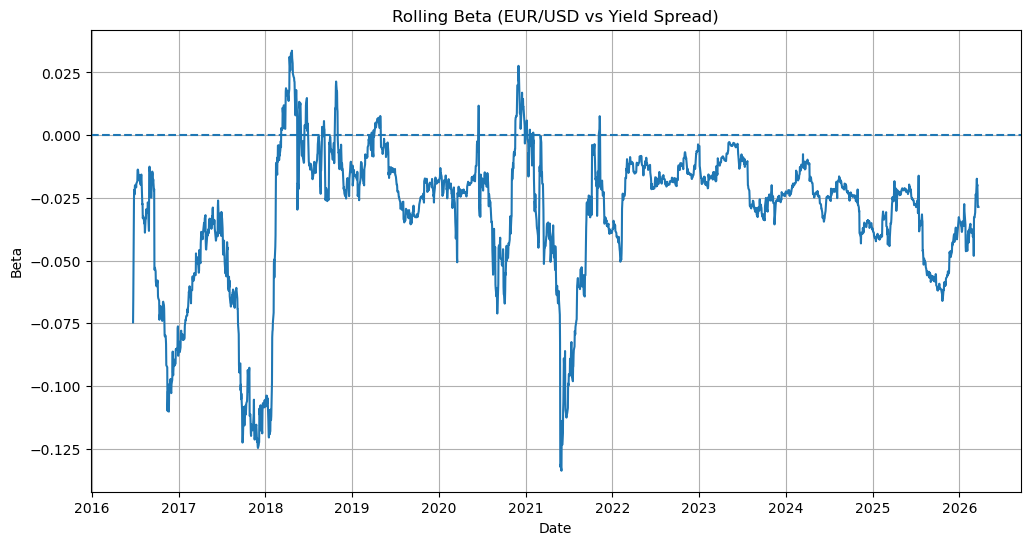

In [75]:
plt.figure(figsize=(12,6))
plt.plot(rolling_ds["Date"], rolling_df["Beta"])
plt.axhline(0, linestyle="--")
plt.title("Rolling Beta (EUR/USD vs Yield Spread)")
plt.ylabel("Beta")
plt.xlabel("Date")
plt.grid(True)
plt.show()

$$
\begin{array}{l}
\quad \textbf{Rolling regression formula:} \\[1em]
\quad \Delta \text{EUR/USD}_t = \alpha_t + \beta_t \cdot \Delta \text{Spread}_t + \varepsilon_t \\[1.5em]
\quad\quad \bullet \ \alpha_t \ \text{and } \beta_t \ \text{are } \textbf{time-varying} \\
\quad\quad \bullet \ \text{Estimated on a } \textbf{rolling window} \\[1.5em]
\quad \text{At each time } t, \text{ the objective is to estimate } \alpha_t \text{ and } \beta_t \text{ that minimize:} \\[1em]
\quad \{\alpha_t, \beta_t\} = \arg\min_{\alpha, \beta} \sum_{i=t-W+1}^{t} 
\left( \Delta \text{EUR/USD}_i - \alpha - \beta \cdot \Delta \text{Spread}_i \right)^2 \\[1.5em]
\quad \text{where } W \text{ denotes the window size (e.g., } W = 60 \text{ days).} \\[1em]
\quad \text{Only the last } W \text{ observations are used at each point in time.} \\[1em]
\quad \beta_t \ \text{measures the } \textbf{local sensitivity} \text{ of EUR/USD to the yield spread.}
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{$\beta$ is predominantly negative} \\[0.5em]
\quad\quad \bullet \ \text{The coefficient is mostly below zero} \\
\quad\quad \bullet \ \text{Confirms the core hypothesis:} \\
\quad\quad \quad \text{Higher US--EU yield spread } \Rightarrow \ \text{lower EUR/USD (USD appreciation)} \\
\quad\quad \bullet \ \text{Consistent with standard FX theory} \\[1.5em]
\quad \textbf{$\beta$ is highly time-varying} \\[0.5em]
\quad\quad \bullet \ \text{Ranges from } \sim -0.12 \ \text{(strong relationship) to } \sim 0 \ \text{or slightly positive} \\
\quad\quad \quad \text{(weak or no relationship)} \\
\quad\quad \bullet \ \text{Indicates that the EUR/USD--spread relationship is } \textbf{regime-dependent} \\[1.5em]
\quad \textbf{Crisis amplification} \\[0.5em]
\quad\quad \bullet \ \text{2017--2018: strong negative } \beta \\
\quad\quad \bullet \ \text{2020--2021 (COVID): heightened volatility and instability} \\
\quad\quad \bullet \ \text{2022 (inflation/war shock): extreme negative } \beta \ (\sim -0.13) \\[1.5em]
\quad \textbf{Economic interpretation:} \\[0.5em]
\quad \text{During periods of macroeconomic stress, the yield spread becomes a dominant driver} \\
\quad \text{of exchange rate dynamics.}
\end{array}
$$

$$
\begin{array}{l}
\quad \textbf{Trading implications} \\[0.8em]
\quad\quad \bullet \ \text{When } |\beta| \text{ is high } \Rightarrow \ \text{the spread provides a } \textbf{tradable signal} \\
\quad\quad \bullet \ \text{When } \beta \approx 0 \Rightarrow \ \text{the spread contains } \textbf{little to no information} \\[1.2em]
\quad \textbf{This suggests a state-dependent strategy} \\[1.5em]
\quad \textbf{Conclusion} \\[0.5em]
\quad \text{The rolling regression demonstrates that the relationship between EUR/USD and the yield} \\
\quad \text{spread is } \textbf{highly time-varying}. \text{ Although the coefficient is predominantly negative,} \\
\quad \text{its magnitude fluctuates substantially over time, indicating that the influence of interest} \\
\quad \text{rate differentials is not constant but intensifies under specific macroeconomic regimes.} \\[1em]
\quad \text{This provides evidence of } \textbf{structural instability} \text{ and underscores the limitations of} \\
\quad \text{static models.}
\end{array}
$$